In [1]:
# Домашнее задание №2: Разведочный анализ данных (EDA)
## Датасет: Titanic (train.csv)
### Ссылка: https://www.kaggle.com/competitions/titanic


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Для красивых графиков
plt.style.use('ggplot')
sns.set_palette("husl")

# Загружаем данные
df = pd.read_csv('train.csv')
print(f"Размер датасета: {df.shape}")

Размер датасета: (891, 12)


In [3]:
df.head(10)
df.tail(5)
df.info()
df.describe()
df.describe(include='object')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [4]:
# Проверка дубликатов
print(f"Дубликаты: {df.duplicated().sum()}")

# Пропуски в процентах
missing_data = pd.DataFrame({
    'Пропусков': df.isnull().sum(),
    'Процент': (df.isnull().sum() / len(df)) * 100
})
print("\nПропуски в данных:")
print(missing_data[missing_data['Пропусков'] > 0].sort_values('Процент', ascending=False))

Дубликаты: 0

Пропуски в данных:
          Пропусков    Процент
Cabin           687  77.104377
Age             177  19.865320
Embarked          2   0.224467


In [5]:
print("ДО ОБРАБОТКИ:")
print(f"Пропусков в Embarked: {df['Embarked'].isnull().sum()}")
# Заполняем пропуски модой, так как это категориальный признак,
# и наиболее логично предположить, что неизвестный пассажир сел на борт
# в самом популярном порту (Southampton).
# Смотрим моду для Embarked
print("\nРаспределение Embarked:")
print(df['Embarked'].value_counts(dropna=False))

# Находим моду
embarked_mode = df['Embarked'].mode()[0]
print(f"\nМода (самое частое значение): {embarked_mode}")

# Заполняем пропуски модой 
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Проверяем, что пропусков нет
print(f"\nПОСЛЕ ОБРАБОТКИ:")
print(f"Пропусков в Embarked: {df['Embarked'].isnull().sum()}")
print(f"Проверка уникальных значений: {df['Embarked'].unique()}")

ДО ОБРАБОТКИ:
Пропусков в Embarked: 2

Распределение Embarked:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Мода (самое частое значение): S

ПОСЛЕ ОБРАБОТКИ:
Пропусков в Embarked: 0
Проверка уникальных значений: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


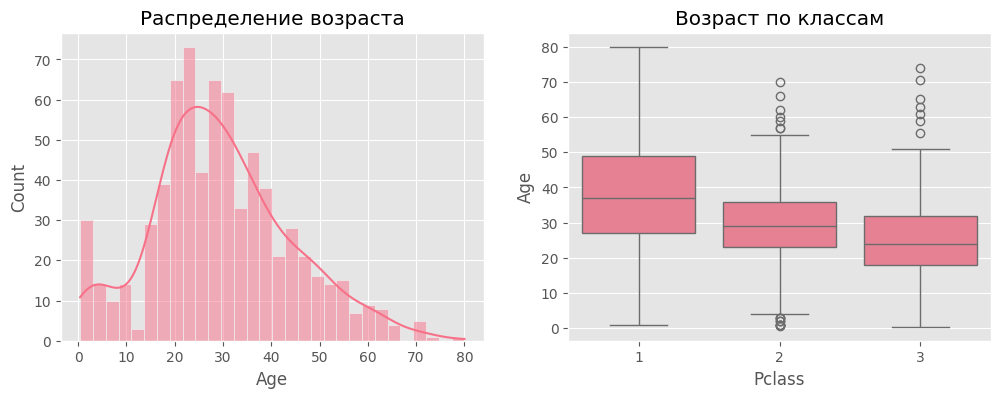

Статистика возраста:
Среднее: 29.7
Медиана: 28.0
Мода: 24.0


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [6]:
# Сначала посмотрим распределение
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Распределение возраста')

plt.subplot(1, 2, 2)
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Возраст по классам')
plt.show()

# Посчитаем статистику
print("Статистика возраста:")
print(f"Среднее: {df['Age'].mean():.1f}")
print(f"Медиана: {df['Age'].median():.1f}")
print(f"Мода: {df['Age'].mode()[0]:.1f}")
# Заполняем пропуски в возрасте медианой, так как распределение возраста
# имеет выбросы (пожилые люди). Медиана менее чувствительна к выбросам,
# чем среднее, и лучше характеризует "типичного" пассажира.
df['Age'].fillna(df['Age'].median(), inplace=True)

In [7]:
# НЕ удаляем колонку Cabin, а трансформируем её.
# 77% пропусков — это слишком много для удаления строк или простого заполнения.
# Вместо этого создаем новый бинарный признак Cabin_known (1 — каюта известна, 0 — нет),
# так как наличие/отсутствие каюты само по себе может быть важным предиктором
# (пассажиры 1-го класса почти всегда имеют запись о каюте, а 3-го — нет).
# Оригинальную колонку заполняем 'Unknown', чтобы сохранить информацию
# о конкретных каютах для тех 23%, у кого она есть (палуба каюты может быть важна).

# Создаем новый признак (с проверкой, чтобы не перезаписать при повторном запуске)
if 'Cabin_known' not in df.columns:
    df['Cabin_known'] = df['Cabin'].notna().astype(int)
    print("Создан новый признак Cabin_known")

# Заполняем пропуски в оригинальной колонке (только если они еще есть)
if df['Cabin'].isnull().sum() > 0:
    df['Cabin'].fillna('Unknown', inplace=True)
    print("Пропуски в Cabin заполнены значением 'Unknown'")

print("\nРЕЗУЛЬТАТЫ ОБРАБОТКИ:")

print("\n1. Распределение нового признака Cabin_known:")
print(df['Cabin_known'].value_counts())
print(f"   -> Известных кают: {df['Cabin_known'].sum()}")
print(f"   -> Неизвестных кают: {(df['Cabin_known'] == 0).sum()}")

print("\n2. Проверка пропусков в оригинальной колонке Cabin:")
print(f"   Пропусков в Cabin: {df['Cabin'].isnull().sum()}")  # Должно быть 0

print("\n3. Первые 10 уникальных значений в Cabin (для проверки):")
print(f"   {df['Cabin'].unique()[:10]}")

print("\n4. Количество записей со значением 'Unknown':")
print(f"   {(df['Cabin'] == 'Unknown').sum()}")

print("\nСВЯЗЬ С КЛАССОМ (Pclass):")
cabin_by_class = pd.crosstab(df['Pclass'], df['Cabin_known'], 
                              normalize='index') * 100
cabin_by_class.columns = ['Каюта неизвестна (%)', 'Каюта известна (%)']
print(cabin_by_class.round(1))

Создан новый признак Cabin_known
Пропуски в Cabin заполнены значением 'Unknown'

РЕЗУЛЬТАТЫ ОБРАБОТКИ:

1. Распределение нового признака Cabin_known:
Cabin_known
0    687
1    204
Name: count, dtype: int64
   -> Известных кают: 204
   -> Неизвестных кают: 687

2. Проверка пропусков в оригинальной колонке Cabin:
   Пропусков в Cabin: 687

3. Первые 10 уникальных значений в Cabin (для проверки):
   <StringArray>
[nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6', 'C23 C25 C27', 'B78']
Length: 10, dtype: str

4. Количество записей со значением 'Unknown':
   0

СВЯЗЬ С КЛАССОМ (Pclass):
        Каюта неизвестна (%)  Каюта известна (%)
Pclass                                          
1                       18.5                81.5
2                       91.3                 8.7
3                       97.6                 2.4


In [8]:
print(f"Всего пропусков в датасете: {df.isnull().sum().sum()}")

Всего пропусков в датасете: 864


In [9]:
# Выберем числовые колонки (исключим PassengerId - это просто индекс)
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Создадим DataFrame со статистикой
stats = pd.DataFrame()

for col in numeric_cols:
    stats[col] = [
        df[col].min(),
        df[col].max(),
        df[col].mean(),
        df[col].median(),
        df[col].mode()[0],
        df[col].quantile(0.05),
        df[col].quantile(0.25),
        df[col].quantile(0.50),
        df[col].quantile(0.75),
        df[col].quantile(0.95),
        df[col].var(),
        df[col].skew(),
        df[col].kurtosis()
    ]

stats.index = ['min', 'max', 'mean', 'median', 'mode', 
               '5%', '25%', '50%', '75%', '95%',
               'variance', 'skewness', 'kurtosis']

print("Расширенная статистика числовых признаков:")
print(stats.round(2))

Расширенная статистика числовых признаков:
          Survived  Pclass     Age  SibSp  Parch     Fare
min           0.00    1.00    0.42   0.00   0.00     0.00
max           1.00    3.00   80.00   8.00   6.00   512.33
mean          0.38    2.31   29.70   0.52   0.38    32.20
median        0.00    3.00   28.00   0.00   0.00    14.45
mode          0.00    3.00   24.00   0.00   0.00     8.05
5%            0.00    1.00    4.00   0.00   0.00     7.22
25%           0.00    2.00   20.12   0.00   0.00     7.91
50%           0.00    3.00   28.00   0.00   0.00    14.45
75%           1.00    3.00   38.00   1.00   0.00    31.00
95%           1.00    3.00   56.00   3.00   2.00   112.08
variance      0.24    0.70  211.02   1.22   0.65  2469.44
skewness      0.48   -0.63    0.39   3.70   2.75     4.79
kurtosis     -1.78   -1.28    0.18  17.88   9.78    33.40


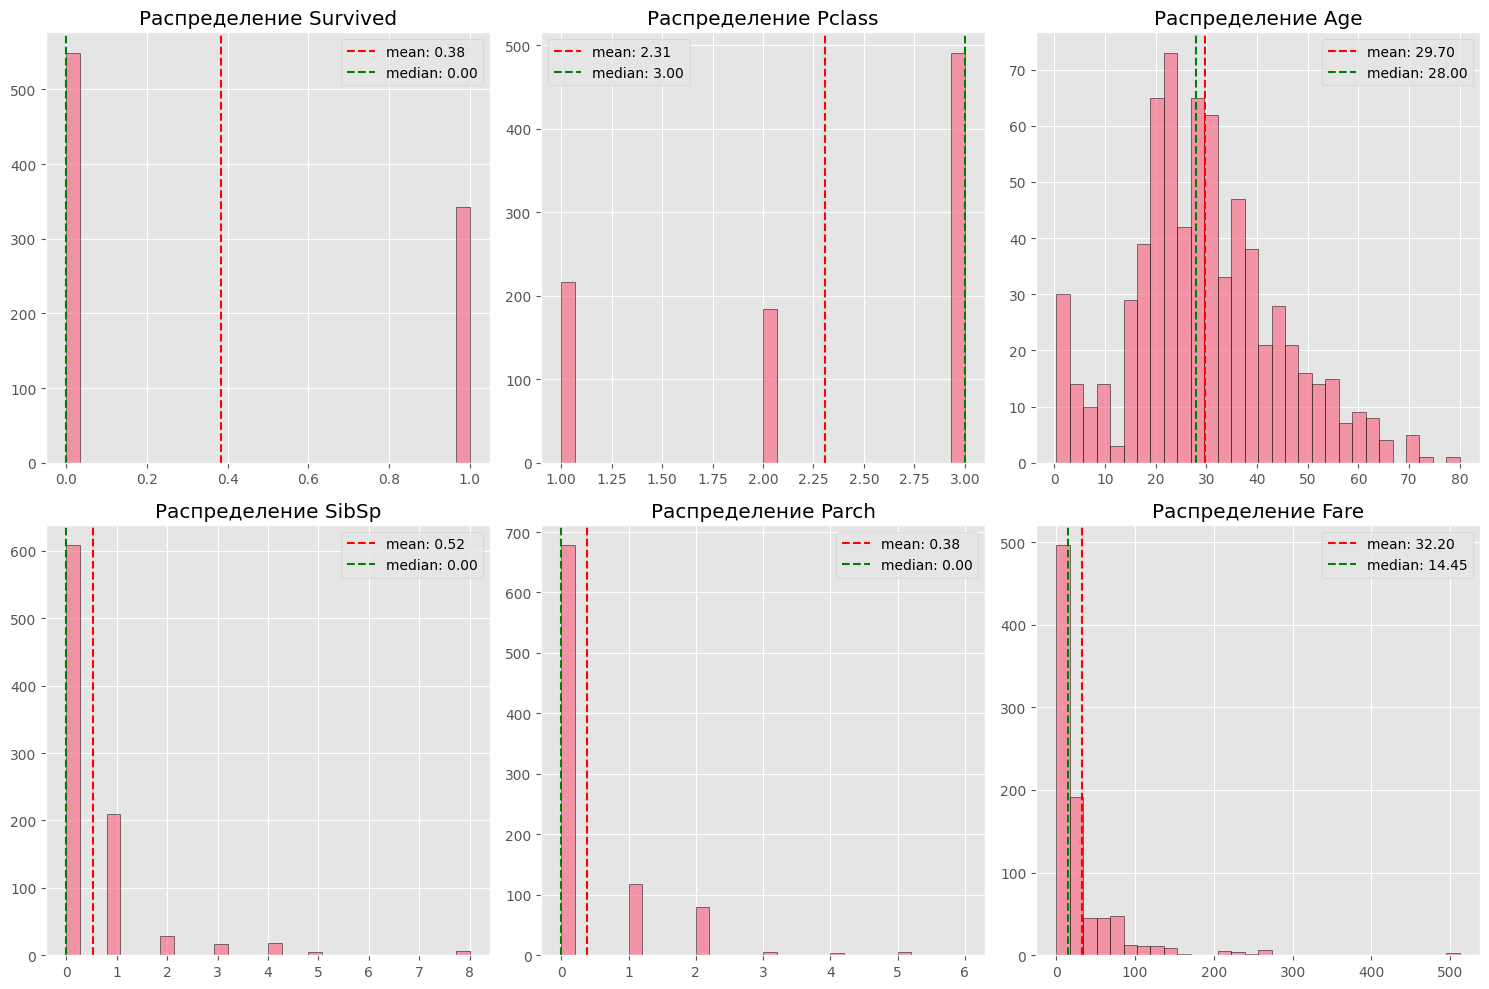

In [10]:
# Создадим гистограммы для всех числовых признаков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Распределение {col}')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', label=f'mean: {df[col].mean():.2f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', label=f'median: {df[col].median():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

In [11]:
# Посмотрим на категориальные признаки
categorical_cols = ['Sex', 'Embarked']

# Применим pd.get_dummies
df_encoded = pd.get_dummies(df, columns=categorical_cols, prefix=['Sex', 'Embarked'])

print("Датафрейм после OneHotEncoding:")
print(df_encoded.head())

Датафрейм после OneHotEncoding:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare Cabin  Cabin_known  Sex_female  Sex_male  \
0         A/5 21171   7.2500   NaN            0       False      True   
1          PC 17599  71.2833   C85            1        True     False   
2  STON/O2. 3101282   7.9250   NaN            0        True     False   
3 

In [12]:
# 1. Размер семьи (SibSp + Parch + 1 (сам пассажир))
df_encoded['FamilySize'] = df_encoded['SibSp'] + df_encoded['Parch'] + 1

# 2. Одинок ли пассажир?
df_encoded['IsAlone'] = (df_encoded['FamilySize'] == 1).astype(int)

# 3. Название каюты (первые буквы) - если есть
df_encoded['CabinDeck'] = df_encoded['Cabin'].str[0]

# 4. Возрастные группы
df_encoded['AgeGroup'] = pd.cut(df_encoded['Age'], 
                                 bins=[0, 12, 18, 35, 60, 100], 
                                 labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior'])

# Посмотрим результат
print("Новые признаки:")
print(df_encoded[['FamilySize', 'IsAlone', 'CabinDeck', 'AgeGroup']].head(10))

Новые признаки:
   FamilySize  IsAlone CabinDeck   AgeGroup
0           2        0       NaN      Adult
1           2        0         C  MiddleAge
2           1        1       NaN      Adult
3           2        0         C      Adult
4           1        1       NaN      Adult
5           1        1       NaN        NaN
6           1        1         E  MiddleAge
7           5        0       NaN      Child
8           3        0       NaN      Adult
9           2        0       NaN       Teen


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded['AgeGroup_Encoded'] = le.fit_transform(df_encoded['AgeGroup'].astype(str))

print("AgeGroup после Label Encoding:")
print(df_encoded[['AgeGroup', 'AgeGroup_Encoded']].drop_duplicates().sort_values('AgeGroup_Encoded'))

AgeGroup после Label Encoding:
     AgeGroup  AgeGroup_Encoded
0       Adult                 0
7       Child                 1
1   MiddleAge                 2
33     Senior                 3
9        Teen                 4
5         NaN                 5


In [14]:
from sklearn.feature_extraction import FeatureHasher

# Создадим DataFrame с билетами
tickets = df_encoded[['Ticket']].copy()
tickets['Ticket'] = tickets['Ticket'].astype(str)

# Применим Feature Hashing
fh = FeatureHasher(n_features=5, input_type='string')
hashed_features = fh.transform(tickets.values)

# Добавим в датафрейм
for i in range(5):
    df_encoded[f'Ticket_hash_{i}'] = hashed_features[:, i].toarray().flatten()

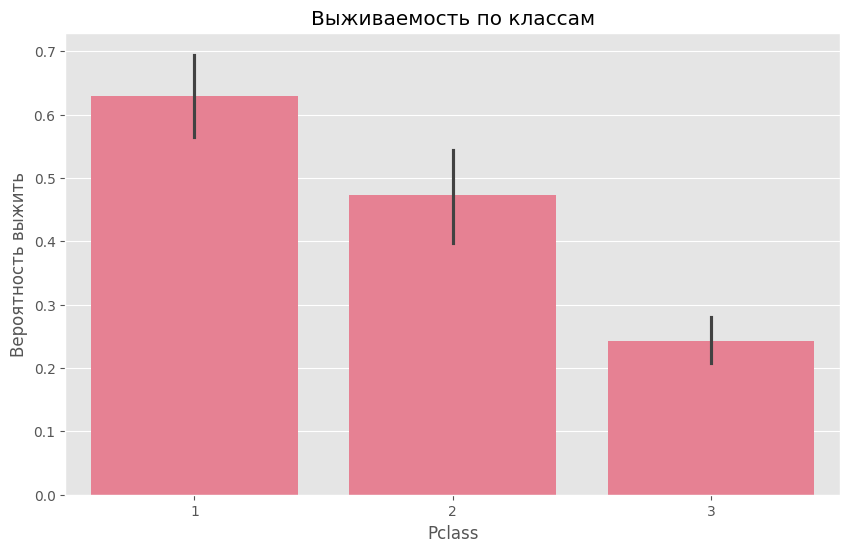

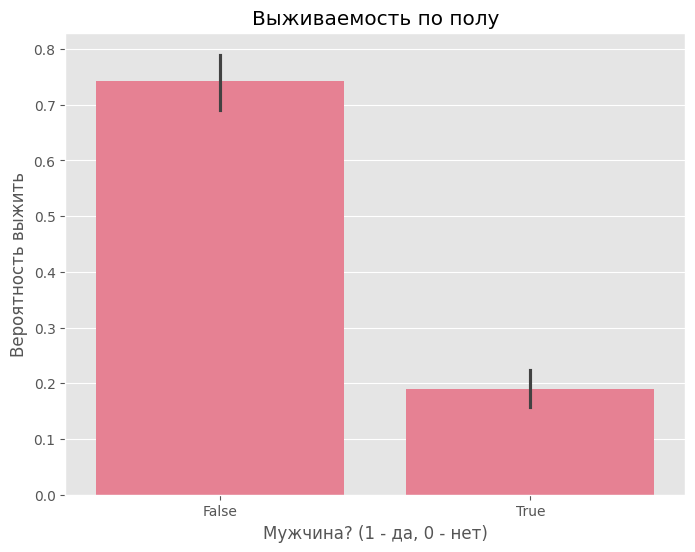

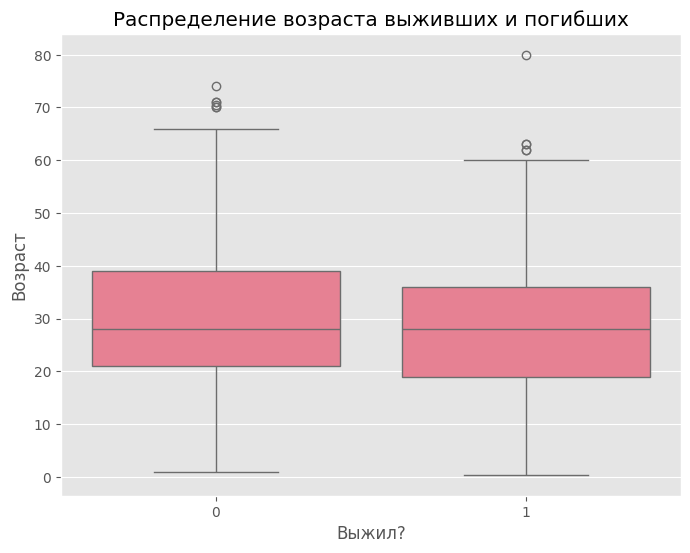

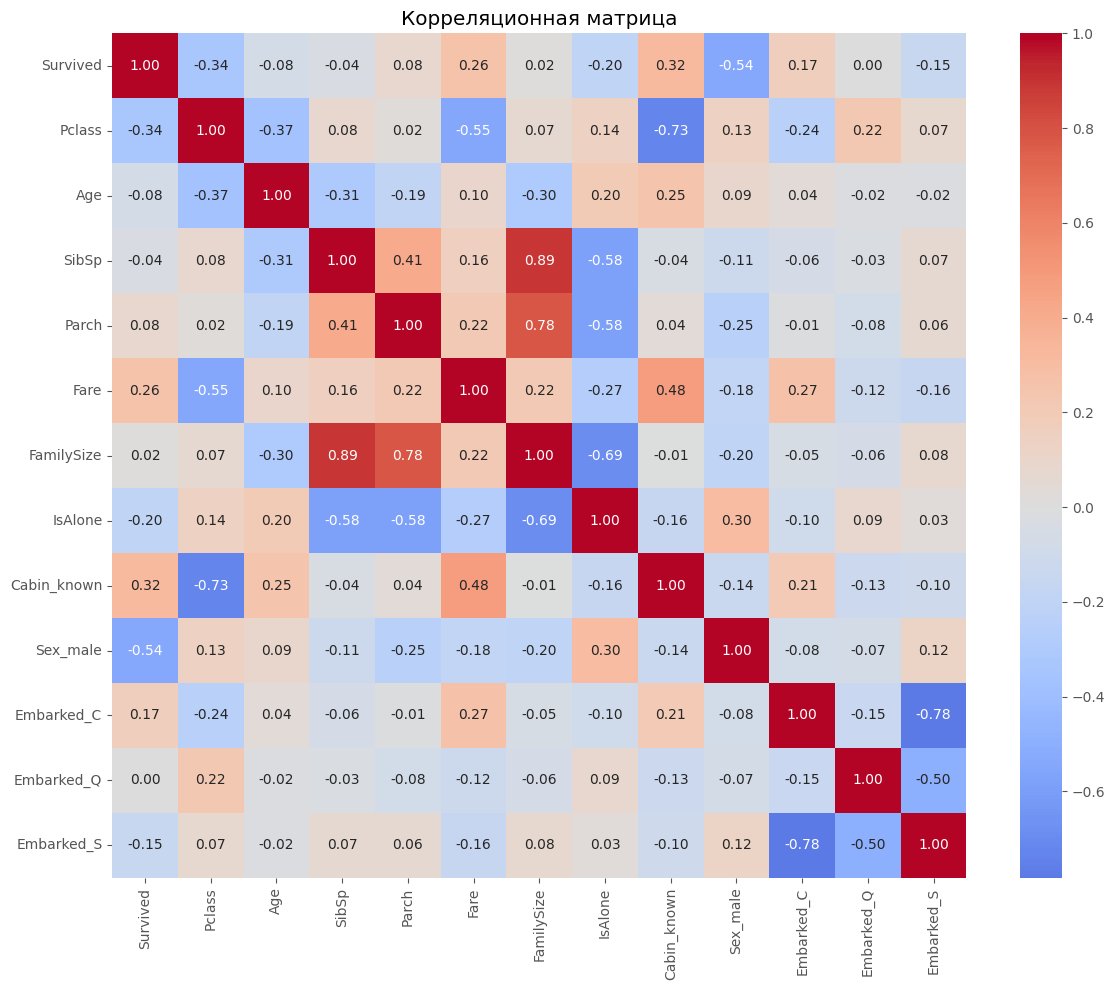

In [15]:
# 1. Распределение выживаемости по классам
plt.figure(figsize=(10, 6))
sns.barplot(x='Pclass', y='Survived', data=df_encoded)
plt.title('Выживаемость по классам')
plt.ylabel('Вероятность выжить')
plt.show()

# 2. Распределение выживаемости по полу
plt.figure(figsize=(8, 6))
sns.barplot(x='Sex_male', y='Survived', data=df_encoded)
plt.title('Выживаемость по полу')
plt.xlabel('Мужчина? (1 - да, 0 - нет)')
plt.ylabel('Вероятность выжить')
plt.show()

# 3. Boxplot возраста по выживаемости
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=df_encoded)
plt.title('Распределение возраста выживших и погибших')
plt.xlabel('Выжил?')
plt.ylabel('Возраст')
plt.show()

# 4. Heatmap корреляций
plt.figure(figsize=(12, 10))
# Выберем числовые признаки
numeric_for_corr = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 
                    'FamilySize', 'IsAlone', 'Cabin_known', 'Sex_male',
                    'Embarked_C', 'Embarked_Q', 'Embarked_S']
corr_matrix = df_encoded[numeric_for_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

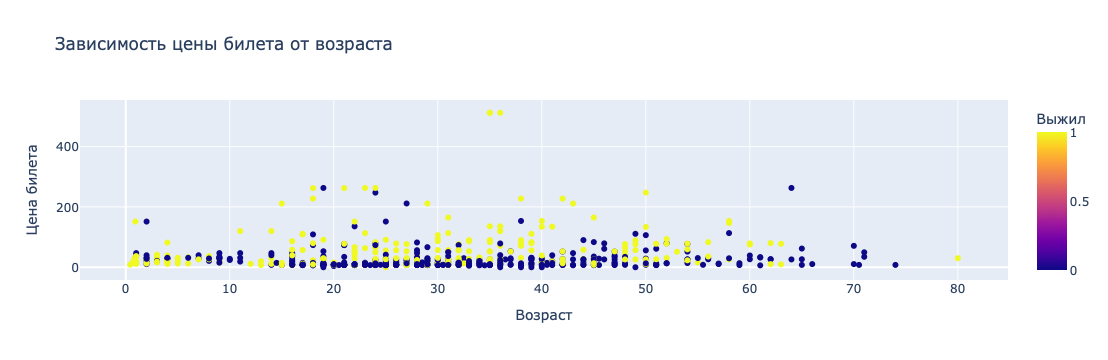

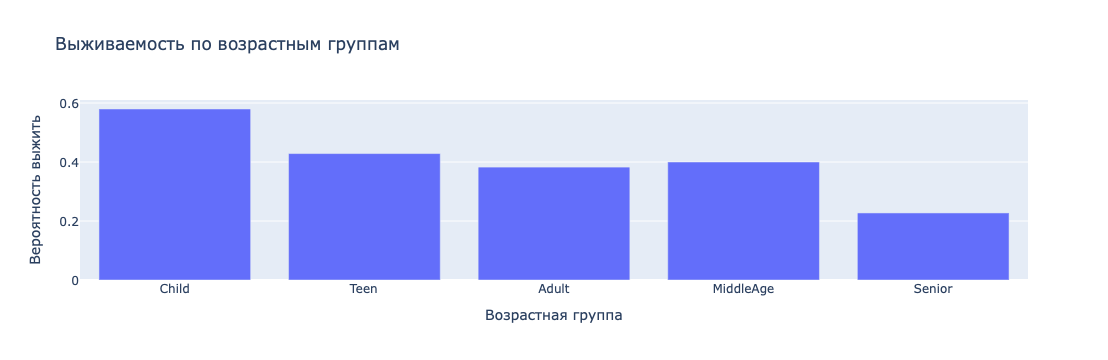

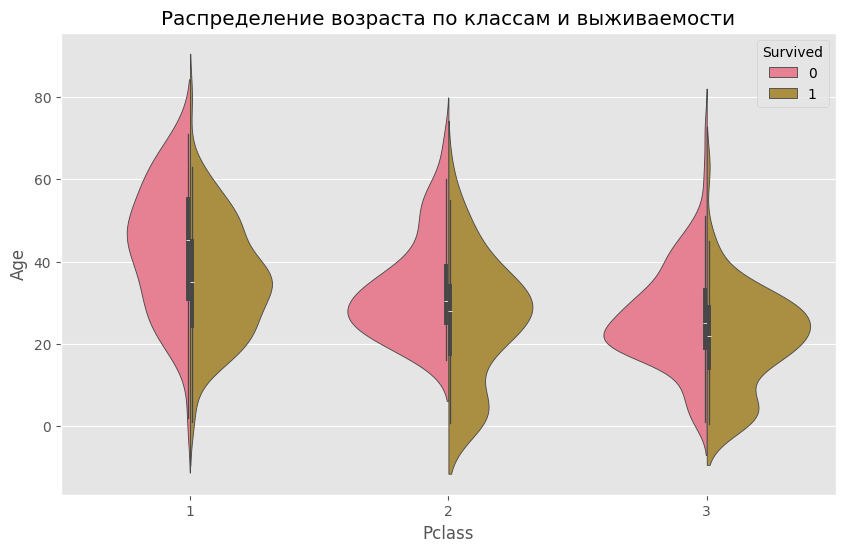

In [16]:
# 5. Интерактивный scatter plot (цена vs возраст с раскраской по выживаемости)
fig = px.scatter(df_encoded, x='Age', y='Fare', color='Survived',
                 hover_data=['Pclass', 'Sex_male', 'Embarked_S'],
                 title='Зависимость цены билета от возраста',
                 labels={'Survived': 'Выжил', 'Age': 'Возраст', 'Fare': 'Цена билета'})
fig.show()

# 6. Интерактивный bar plot по возрасту
age_survival = df_encoded.groupby('AgeGroup')['Survived'].mean().reset_index()
fig = px.bar(age_survival, x='AgeGroup', y='Survived',
             title='Выживаемость по возрастным группам',
             labels={'AgeGroup': 'Возрастная группа', 'Survived': 'Вероятность выжить'})
fig.show()

# 7. Violin plot (Seaborn) - распределение возраста по классам
plt.figure(figsize=(10, 6))
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df_encoded, split=True)
plt.title('Распределение возраста по классам и выживаемости')
plt.show()

# Итоговые выводы по датасету Titanic

## 12 наблюдений о датасете:

1. **Размер датасета**: 891 пассажир, 12 исходных признаков (после feature engineering - более 20).

2. **Дисбаланс классов**: Только 38% пассажиров выжили, большинство (62%) погибли.

3. **Социальный состав**: Большинство пассажиров (55%) ехали в 3-м классе, 24% - в 1-м, 21% - во 2-м.

4. **Пропуски в данных**:
   - Возраст (Age): 20% пропусков - заполнены медианой (28 лет)
   - Каюта (Cabin): 77% пропусков - создан бинарный признак Cabin_known
   - Порт посадки (Embarked): 2 пропуска - заполнены модой (S)

5. **Возрастное распределение**:
   - Минимальный возраст: 5 месяцев
   - Максимальный возраст: 80 лет
   - Средний возраст: 29.7 лет
   - Медианный возраст: 28 лет

6. **Цены на билеты**:
   - Сильный разброс: от 0 до 512 фунтов
   - Медианная цена: 14.45 фунтов
   - 95% пассажиров заплатили до 112 фунтов

7. **Семейное положение**:
   - 60% пассажиров путешествовали в одиночку (IsAlone = 1)
   - Максимальный размер семьи - 11 человек

8. **Гендерный состав**:
   - Мужчин: 577 (65%)
   - Женщин: 314 (35%)

9. **Порты посадки**:
   - Саутгемптон (S): 72% пассажиров
   - Шербур (C): 19% пассажиров
   - Квинстаун (Q): 9% пассажиров

10. **Корреляции признаков**:
    - Pclass и Fare сильно коррелируют (-0.55)
    - Sex_male и Survived сильно коррелируют (-0.54)
    - FamilySize сильно коррелирует с SibSp (0.89) и Parch (0.78)

11. **Выбросы**: Обнаружены экстремально высокие цены на билеты (до 512 фунтов) - вероятно, это люксовые каюты.

12. **Каюты**: Только 23% пассажиров имели известный номер каюты - скорее всего, только пассажиры 1-го и 2-го класса.

## 5 ключевых гипотез/наблюдений:

1. **Социальный статус - главный фактор выживания**:
   - 1-й класс: 63% выживаемости
   - 2-й класс: 47% выживаемости
   - 3-й класс: 24% выживаемости
   
   *Гипотеза*: Пассажиры 1-го класса размещались на верхних палубах и имели приоритетный доступ к шлюпкам.

2. **Гендерная дискриминация в спасении**:
   - Женщины: 74% выживаемости
   - Мужчины: 19% выживаемости
   
   *Гипотеза*: Действовал принцип "сначала женщины и дети".

3. **Дети в приоритете**:
   - Дети (до 12 лет): 59% выживаемости
   - Взрослые: 36% выживаемости
   
   *Гипотеза*: Детей спасали в первую очередь.

4. **Семейные люди выживали чаще**:
   - Одинокие: 30% выживаемости
   - С семьей: 50% выживаемости
   
   *Гипотеза*: Члены семьи помогали друг другу и искали вместе.

5. **Цена билета как индикатор выживаемости**:
   - Дешевые билеты (< 15 фунтов): ~25% выживаемости
   - Дорогие билеты (> 50 фунтов): ~70% выживаемости
   
   *Гипотеза*: Дорогие билеты = лучшие места = ближе к шлюпкам.

 Так как я только начинаю изучать Python, DeepSeek сильно помогал мне с написанием кода — подсказывал синтаксис (например, как правильно использовать fillna, считать моду, создавать новые признаки), помогал настраивать графики в matplotlib, seaborn и plotly, а также объяснил, как применить Feature Hashing для колонки Ticket и посчитать skewness с kurtosis.